In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Flatten, Dropout, Input, concatenate
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
num_samples = 1000
time_steps = 50
features = 10
num_classes = 2

X_cnn = np.random.rand(num_samples, time_steps, features)  # CNN input
X_lstm = np.random.rand(num_samples, time_steps, features)  # LSTM input
y = np.random.randint(0, num_classes, num_samples)  # Labels (0 or 1)


In [3]:
# Reshape labels for binary classification
y = y.reshape(-1, 1)

In [4]:

cnn_input = Input(shape=(time_steps, features))
x_cnn = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(cnn_input)
x_cnn = Flatten()(x_cnn)

In [5]:
lstm_input = Input(shape=(time_steps, features))
x_lstm = LSTM(64, return_sequences=False)(lstm_input)

In [6]:
merged = concatenate([x_cnn, x_lstm])
merged = Dense(128, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(1, activation='sigmoid')(merged)  # Sigmoid for binary classification

In [7]:
# Model
model = Model(inputs=[cnn_input, lstm_input], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# Training
history = model.fit([X_cnn, X_lstm], y, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5294 - loss: 0.7486 - val_accuracy: 0.5300 - val_loss: 0.7004
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4948 - loss: 0.7015 - val_accuracy: 0.5500 - val_loss: 0.6911
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6407 - loss: 0.6598 - val_accuracy: 0.5600 - val_loss: 0.6957
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6982 - loss: 0.6281 - val_accuracy: 0.5300 - val_loss: 0.7042
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7055 - loss: 0.5956 - val_accuracy: 0.4750 - val_loss: 0.7323
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7750 - loss: 0.5304 - val_accuracy: 0.4900 - val_loss: 0.7554
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8160 - loss: 0.4715 - val_accuracy: 0.5350 - val_loss: 0.7761
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8262 - loss: 0.4507 - val_accuracy: 0.4900 - v

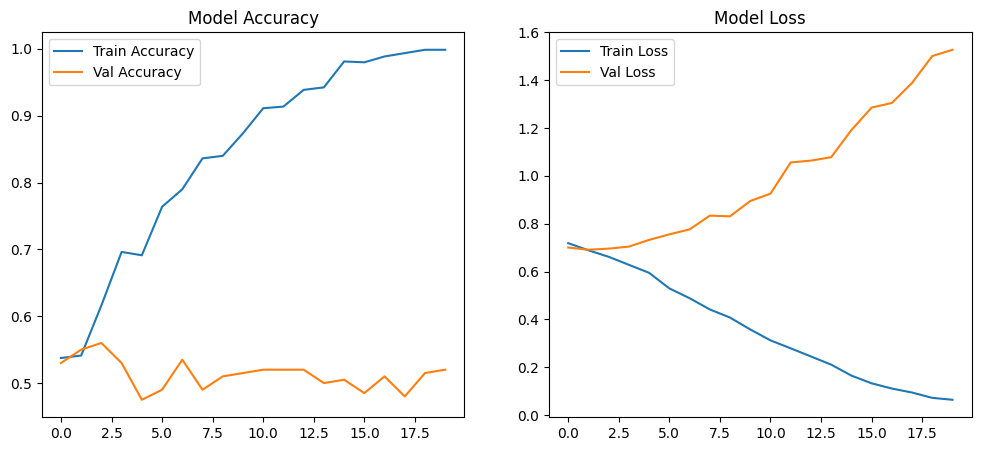

In [9]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

In [10]:
# Predictions
y_pred = model.predict([X_cnn, X_lstm])
y_pred_classes = (y_pred > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


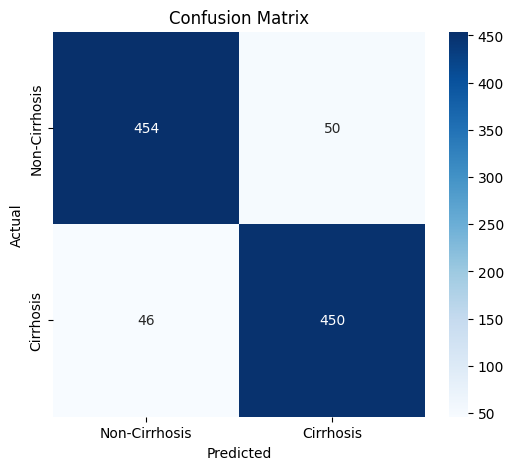

In [11]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Cirrhosis', 'Cirrhosis'], yticklabels=['Non-Cirrhosis', 'Cirrhosis'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
print("Classification Report:\n", classification_report(y, y_pred_classes, target_names=["Non-Cirrhosis", "Cirrhosis"]))


Classification Report:
                precision    recall  f1-score   support

Non-Cirrhosis       0.91      0.90      0.90       504
    Cirrhosis       0.90      0.91      0.90       496

     accuracy                           0.90      1000
    macro avg       0.90      0.90      0.90      1000
 weighted avg       0.90      0.90      0.90      1000

